In [33]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

# Mirrored circuits benchmark

In [34]:
from typing import List

from qiskit import QuantumCircuit, QiskitError
from qiskit.quantum_info import Clifford, random_clifford, StabilizerState
from qiskit.synthesis import synth_clifford_full
import numpy as np

import warnings
warnings.filterwarnings("ignore")

We first construct a base circuit $C=L_mL_{m−1}\cdots L_2L_1$ composed of $m$ Clifford layers $L_i$. 

An example is provided using random Clifford operators and then converting them to circuits, but you may also construct the circuits by yourself.

In [35]:
w = 4  # number of qubits, denoted as w for 'width' of the circuit
m = 5 

base_circuit = QuantumCircuit(w)
clifford_operators_base_circuit = []
for i in range(m):
    random_clifford_operator = random_clifford(w)
    clifford_operators_base_circuit.append(random_clifford_operator)

for clifford_operator in clifford_operators_base_circuit:
    clifford_circuit = synth_clifford_full(clifford_operator, method="greedy")
    base_circuit.compose(clifford_circuit, inplace=True)

### Use the following commented out commands to create your own Clifford circuit
# base_circuit = QuantumCircuit(n_qubits)
# clifford_operators = []
# for i in range(m):
#     clifford_circuit = QuantumCircuit(n_qubits)
#     # Manually add Clifford gates to clifford_circuit, such as X, Y, Z, H, S, Sdg (S dagger), SX, SXdg, CX, CZ, SWAP
#     base_circuit.compose(clifford_circuit, inplace=True)
#     # Ensure that it is indeed Clifford by running the below command
#     # If it does not throw an error, then it is a valid Clifford circuit
#     clifford_operator = Clifford(clifford_circuit) 
#     clifford_operators.append(clifford_operator)

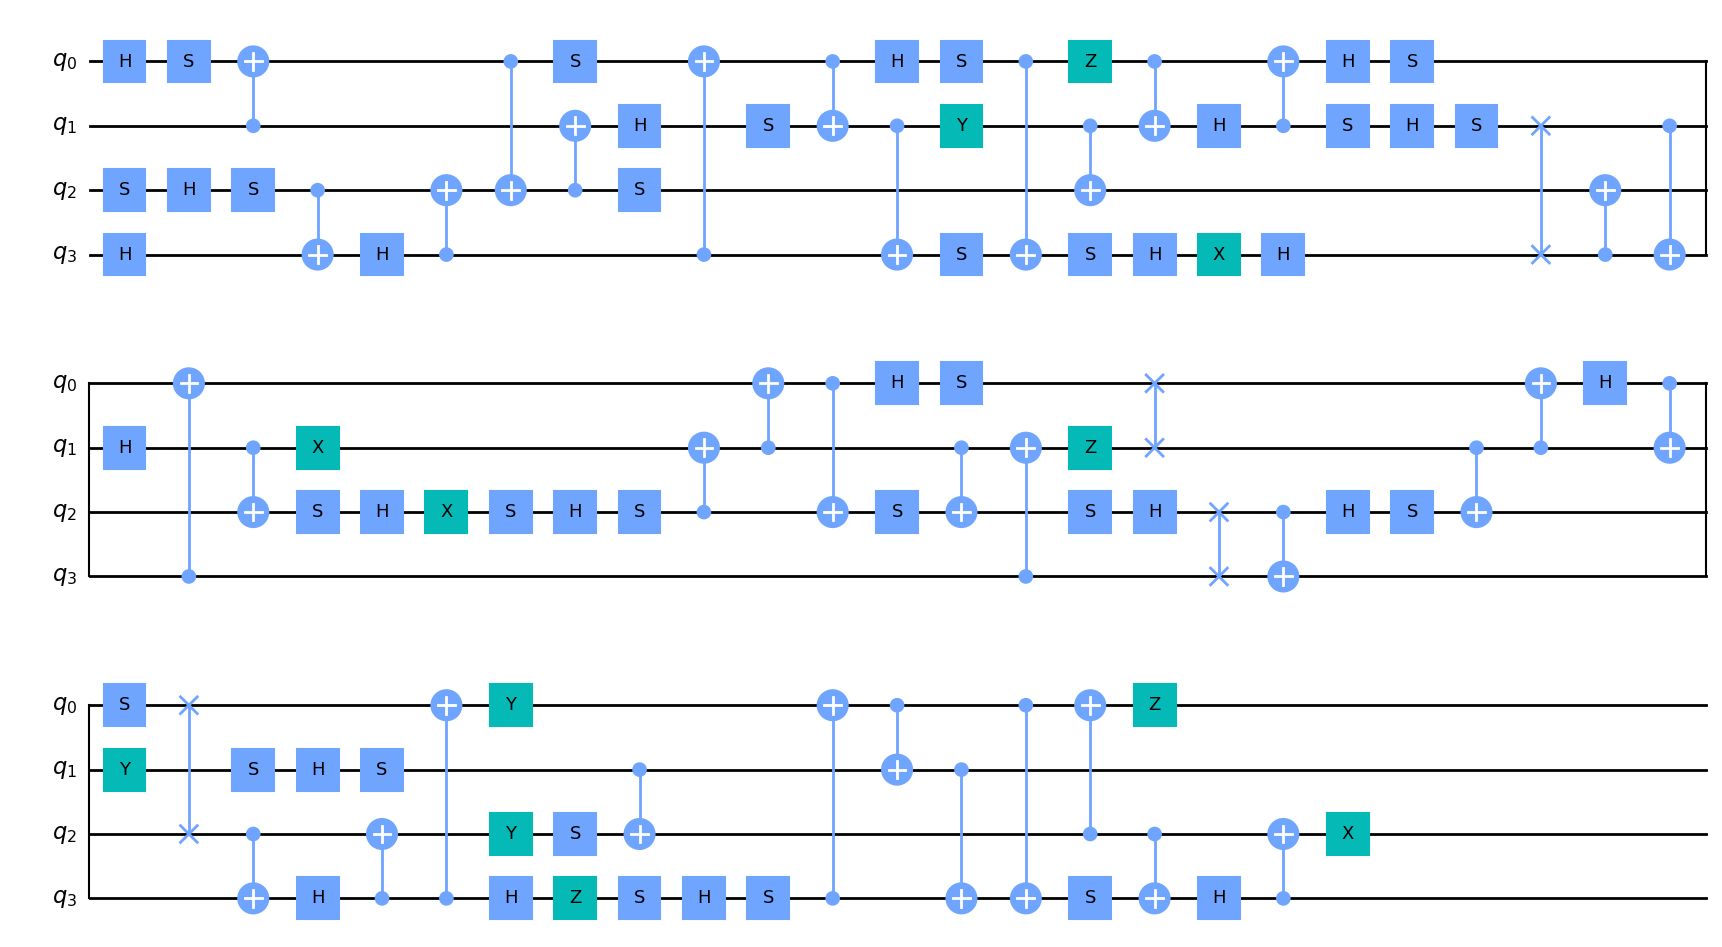

In [36]:
base_circuit.draw(output="mpl")

## Generate random mirrored circuits

In [37]:
def generate_random_mirrored_circuit(input_circuit, circuit_cliffords: List[Clifford]):
    """
        Parameters:
            input_circuit (QuantumCircuit): the base circuit C
            circuit_cliffords (List[Clifford]): the list of Clifford operators that represent each Clifford layer L_i in C
        
        Returns: (mirrored_circuit, mirrored_circuit_clifford)
            mirrored_circuit (QuantumCircuit): the randomly generated mirrored circuit
            mirrored_circuit_clifford (Clifford): the Clifford operator represented the generated mirrored circuit
    """
    try:
        total_clifford = circuit_cliffords[0]
        for clifford in circuit_cliffords[1:]:
            total_clifford = total_clifford.compose(clifford)
        if Clifford(input_circuit) != total_clifford:
            raise ValueError("The provided list of Clifford operators do not match with the input circuit.")
    except QiskitError:
        print("The input circuit is not a valid Clifford circuit.")
    
    n_qubits = int(input_circuit.num_qubits)
    mirrored_circuit = QuantumCircuit(n_qubits)
    
    # L_0: randomly selected single qubit Clifford gates
    circuit_L0 = QuantumCircuit(n_qubits)
    single_qubit_clifford_gates = [circuit_L0.id, circuit_L0.x, circuit_L0.y, circuit_L0.z, circuit_L0.h, 
                                   circuit_L0.s, circuit_L0.sdg, circuit_L0.sx, circuit_L0.sxdg]
    for i in range(n_qubits):
        random_gate = np.random.choice(single_qubit_clifford_gates)
        random_gate(i)
    
    mirrored_circuit.compose(circuit_L0, inplace=True)
        
    # C: directly append input circuit to mirrored_circuit
    mirrored_circuit.compose(input_circuit, inplace=True)
    
    # Q_0: randomly selected Pauli gates
    single_qubit_pauli_gates = [mirrored_circuit.id, mirrored_circuit.x, mirrored_circuit.y, mirrored_circuit.z]
    for i in range(n_qubits):
        random_gate = np.random.choice(single_qubit_pauli_gates)
        random_gate(i)
    
    # C~^{-1}: quasi-inverses of C, where each L~_i^{-1}=Q_i.L_i^{-1} for a random pauli Q_i
    for clifford_Li in reversed(circuit_cliffords):
        inverse_Li = clifford_Li.conjugate().transpose()
        inverse_Li_circuit = synth_clifford_full(inverse_Li, method="greedy")
        mirrored_circuit.compose(inverse_Li_circuit, inplace=True)
        for i in range(n_qubits):
            random_gate = np.random.choice(single_qubit_pauli_gates)
            random_gate(i)
    
    # L_0^{-1}: inverse
    circuit_L0_inverse = circuit_L0.inverse()
    mirrored_circuit.compose(circuit_L0_inverse, inplace=True)
    
    mirrored_circuit_clifford = Clifford(mirrored_circuit)
    
    return mirrored_circuit, mirrored_circuit_clifford
        

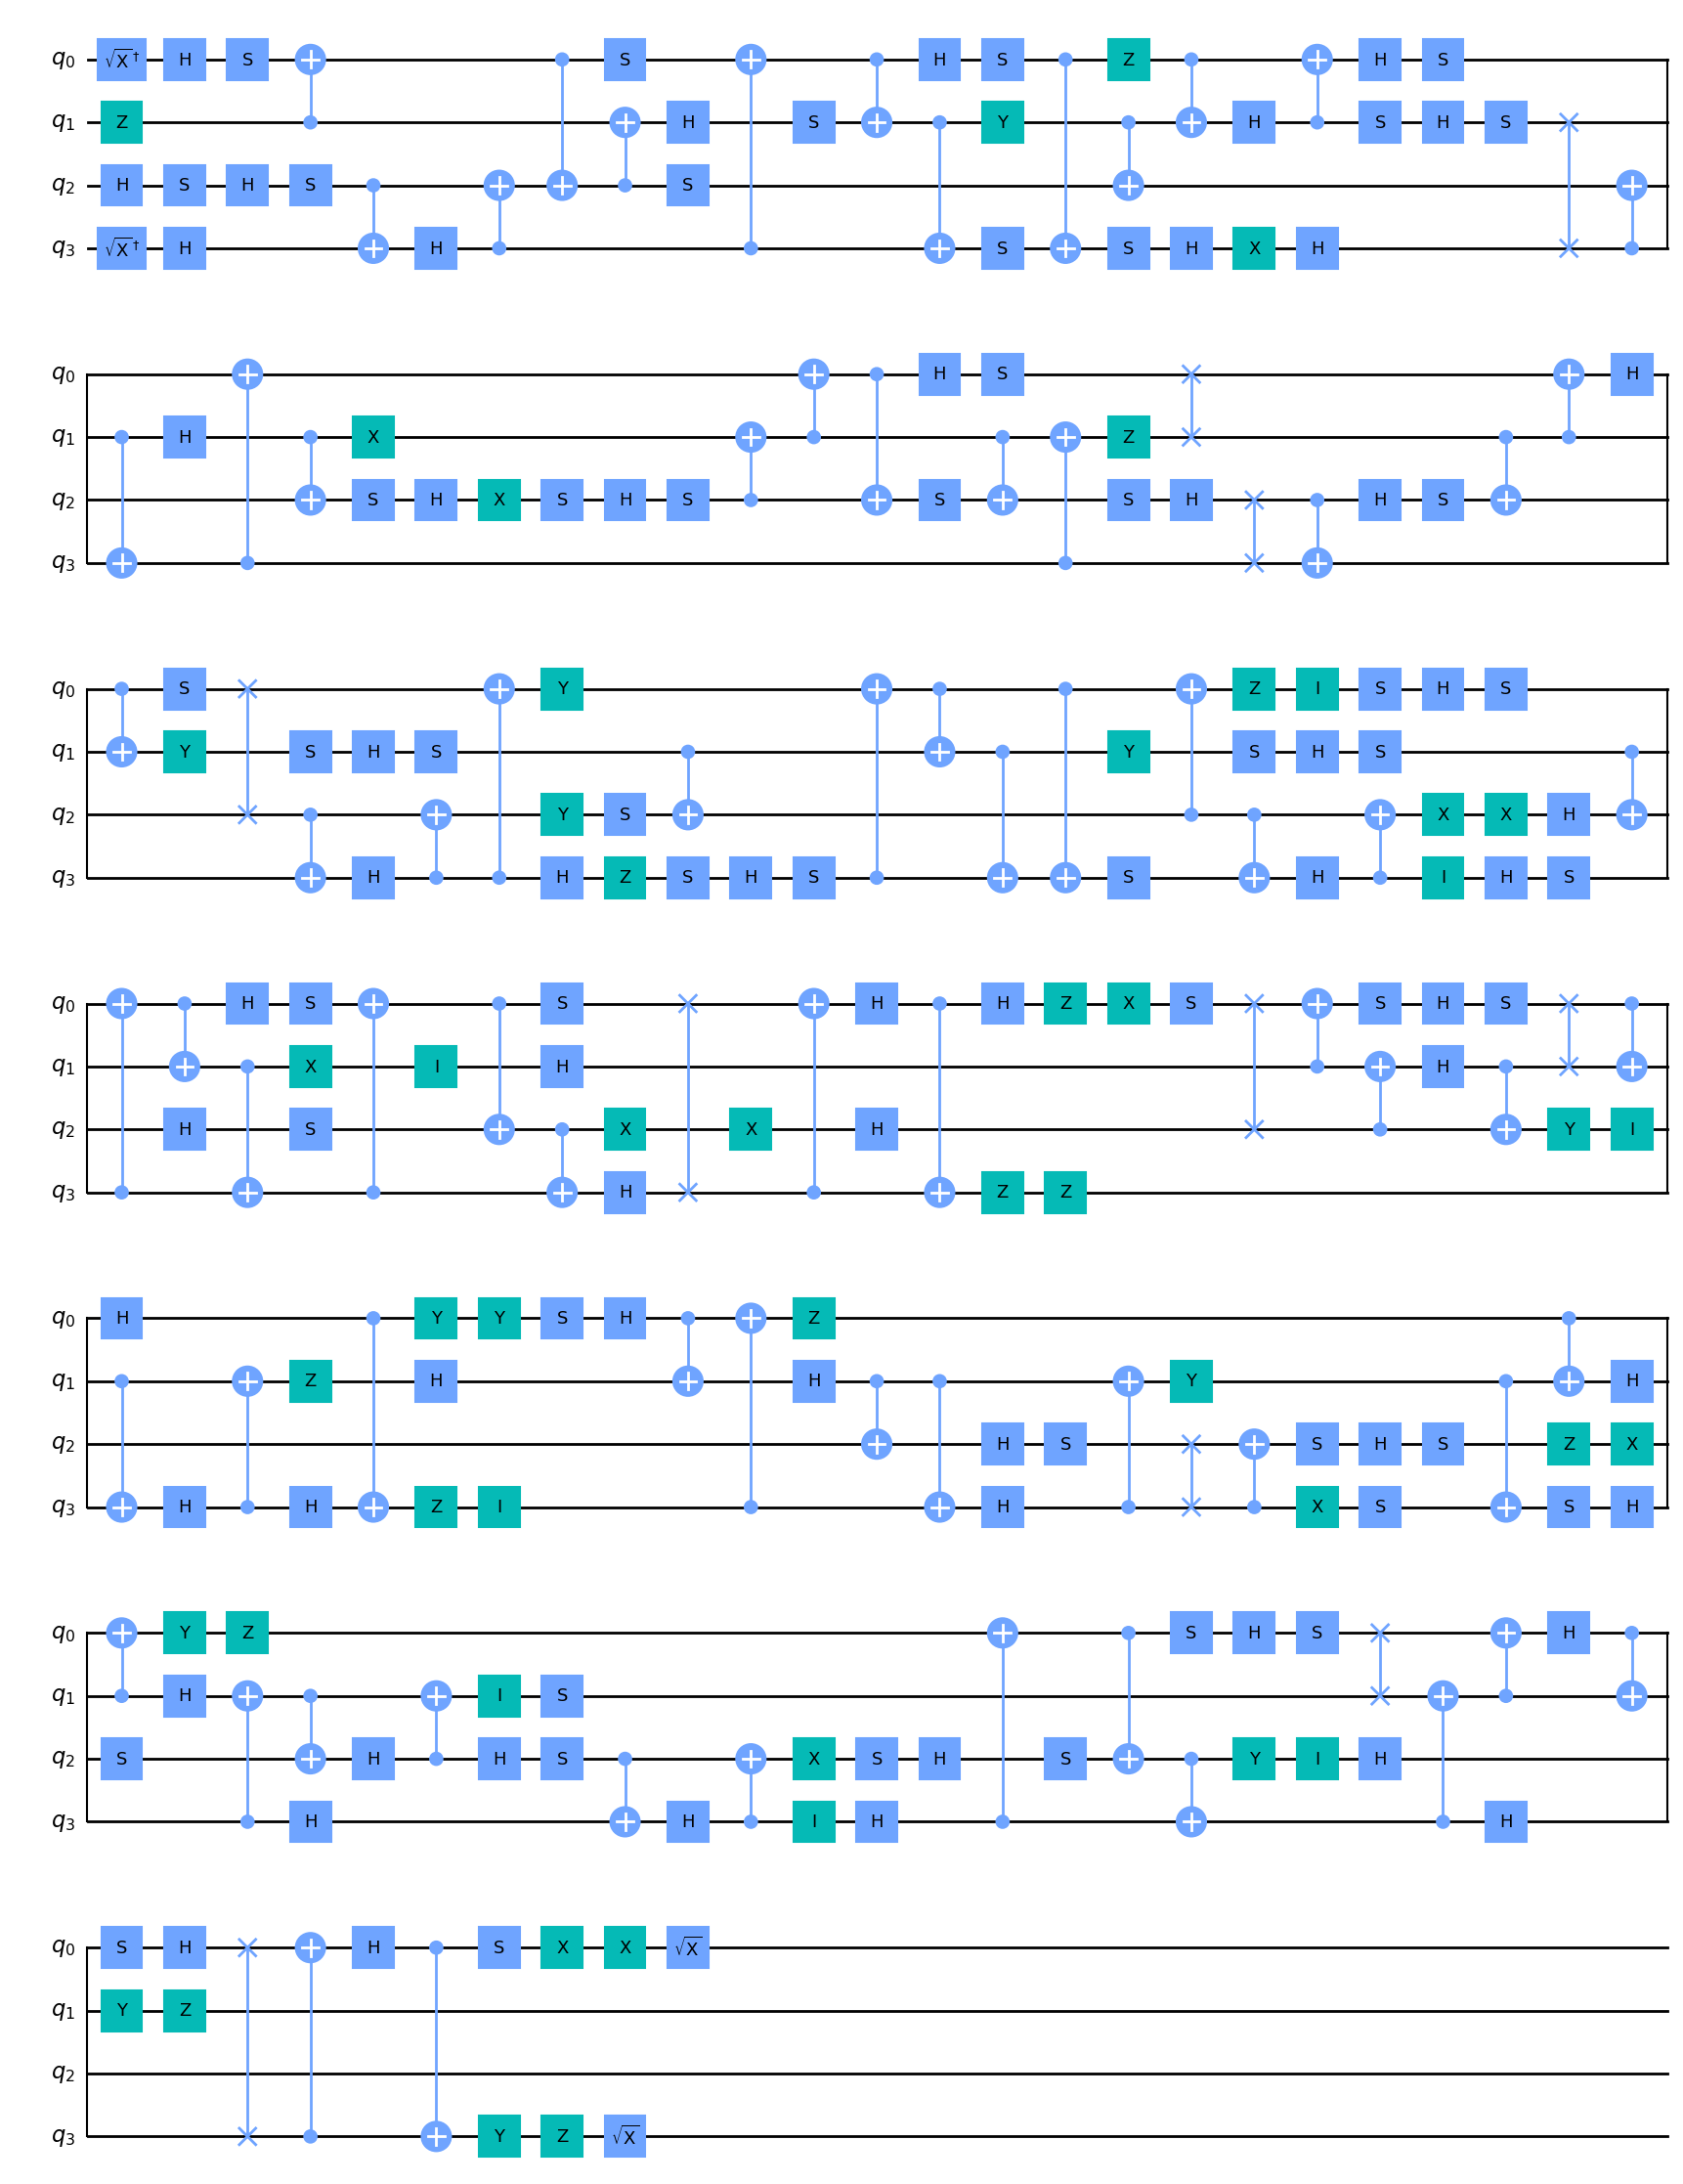

In [38]:
k = 100  # number of mirrored circuits to generate

mirrored_circuits = []
mirrored_circuits_cliffords = []
for i in range(k):
    mirrored_circuit, mirrored_circuit_clifford = generate_random_mirrored_circuit(base_circuit, clifford_operators_base_circuit)
    mirrored_circuits.append(mirrored_circuit)
    mirrored_circuits_cliffords.append(mirrored_circuit_clifford)

# Draw an example
mirrored_circuits[0].draw(output="mpl")

## Efficient classical calculation of the mirrored circuits results using Clifford stabilizers

In [39]:
classical_results = []
shots = 1000

expected_bitstrings = []
for mirrored_circuit in mirrored_circuits:
    prob = StabilizerState(mirrored_circuit).probabilities_dict(decimals=2)
    if len(prob.keys()) != 1:
        raise QiskitError(f"Oops, something is wrong. The output of the mirrored circuit must only be a deterministic bitstring, but it's giving {prob}.")
    expected_bitstrings.append(list(prob.keys())[0])
print(f"The expected output bitstrings of the circuits are: {expected_bitstrings}")

The expected output bitstrings of the circuits are: ['1101', '0110', '1101', '1011', '1000', '1111', '1100', '0101', '0101', '1000', '1010', '0111', '1001', '0111', '1001', '0010', '1010', '1000', '0011', '0010', '0010', '0010', '0100', '0100', '1101', '0001', '0110', '1010', '1011', '1110', '0110', '1111', '1110', '0010', '0010', '0100', '1011', '0000', '0100', '0110', '1101', '1110', '0011', '0101', '1111', '0111', '0100', '1001', '0000', '1110', '0000', '0100', '1001', '0100', '0101', '0001', '0101', '0110', '1010', '1000', '1100', '0100', '0011', '0011', '1111', '1011', '1111', '0110', '0100', '0010', '0100', '1101', '1101', '1010', '1110', '0000', '1111', '1001', '0100', '1101', '0100', '0101', '1111', '1100', '0101', '1111', '1001', '1011', '1010', '0101', '1001', '0100', '0110', '1000', '1100', '0011', '0100', '0001', '0101', '0100']


## Noisy simulation

In [40]:
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
from _helpers.circuit_submitter import CircuitSubmitter

device_name = "noisy_sim"
submitter = CircuitSubmitter("mirrored_circuits", device_name)

# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.set_noise_model(noise_model=noise_model)

In [41]:
shots = 1000

submitter.submit_circuits(shots, qasm_strs=[c.qasm() for c in mirrored_circuits], skip_asking=True)
all_counts = [submitter.convert_counts_to_qiskit(counts) for counts in submitter.retrieve_counts()]

total_polarization = 0
for i in range(k):
    if expected_bitstrings[i] not in all_counts[i].keys():
        continue
    correct_counts = all_counts[i][expected_bitstrings[i]]
    polarization = (correct_counts / shots - 1 / 2 ** w) / (1 - 1 / 2 ** w)
    total_polarization += polarization

total_polarization /= k
print(r"The mirrored circuits average polarization $J_{ave}$ is " + f"{total_polarization}")

Ready to run 100 circuits on noisy_sim with 1000 shots.
Cost: 100 * ($0 + 1000 * $0) = $0.00.
Circuits have been submitted
2024-10-18 11:17:20 All circuits are finished
The mirrored circuits average polarization $J_{ave}$ is 0.2611306666666665
